In [25]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [33]:
f = open('/content/weather.csv', encoding='CP949')
data = csv.reader(f)
header = next(data)

max_wind = 0.0

for row in data:
    if row[2] == '' :
        wind = 0
    else :
        wind = float(row[2])
    if max_wind < wind :
        max_wind = wind

print('지난 10년간 울릉도의 최대 풍속은 ', max_wind, 'm/s')
f.close()

지난 10년간 울릉도의 최대 풍속은  26.0 m/s


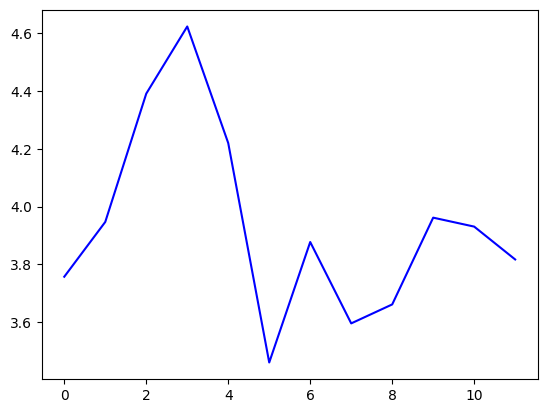

In [32]:
import csv
import matplotlib.pyplot as plt

f = open('/content/weather.csv', encoding='CP949')
data = csv.reader(f)
header = next(data)

monthly_wind = [ 0 for x in range(12) ]
days_counted = [ 0 for x in range(12) ]
for row in data:
    month = int(row[0][5:7])
    if row[3] !=  '' :
        wind = float(row[3])
        monthly_wind[month-1] += wind
        days_counted[month-1] += 1

for i in range(12) :
      monthly_wind[i] /= days_counted[i]

plt.plot(monthly_wind, 'blue')
plt.show()

f.close()

In [31]:
import pandas as pd

weather = pd.read_csv('/content/weather.csv', index_col=0, encoding='CP949')
weather = weather.reset_index() # Convert the index '일시' into a column

print(weather.describe())
print(weather.count())
print(weather[['최대풍속','평균풍속']].mean())
weather['month'] = pd.DatetimeIndex(weather['일시']).month
weather['year'] = pd.DatetimeIndex(weather['일시']).year
means = weather.groupby('month').mean(numeric_only=True)
y_max = weather.groupby('year').max(numeric_only=True)

print(means)

              평균기온         최대풍속         평균풍속
count  3653.000000  3649.000000  3647.000000
mean     12.942102     7.911099     3.936441
std       8.538507     3.029862     1.888473
min      -9.000000     2.000000     0.200000
25%       5.400000     5.700000     2.500000
50%      13.800000     7.600000     3.600000
75%      20.100000     9.700000     5.000000
max      31.300000    26.000000    14.900000
일시      3653
평균기온    3653
최대풍속    3649
평균풍속    3647
dtype: int64
최대풍속    7.911099
평균풍속    3.936441
dtype: float64
            평균기온      최대풍속      평균풍속       year
month                                          
1       1.598387  8.158065  3.757419  2015.5000
2       2.136396  8.225357  3.946786  2015.5053
3       6.250323  8.871935  4.390291  2015.5000
4      11.064667  9.305017  4.622483  2015.5000
5      16.564194  8.548710  4.219355  2015.5000
6      19.616667  6.945667  3.461000  2015.5000
7      23.328387  7.322581  3.877419  2015.5000
8      24.748710  6.853226  3.596129  2014.5000
9

In [41]:
import pandas as pd
df = pd.read_csv('/content/name.csv', encoding='CP949')
display(df.head())

,이름,독서,인성,영어,예술
0,강동원,63,93,67,71
1,송중기,89,83,71,80
2,기태영,83,76,92,98
3,김남길,94,88,73,93
4,류준열,71,83,80,88
